# Imports

In [ ]:
import os
import glob
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import torch
import torchaudio

# Download Dataset

In [ ]:

# Download latest version
path = kagglehub.dataset_download("kenjee/z-by-hp-unlocked-challenge-3-signal-processing")

print("Path to dataset files:", path)

100%|██████████| 604M/604M [00:08<00:00, 76.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing/versions/1


# Load Data file

In [ ]:
Capuchin_file = os.path.join("/","root",".cache","kagglehub","datasets","kenjee","z-by-hp-unlocked-challenge-3-signal-processing","versions","1","Parsed_Capuchinbird_Clips","XC216012-7.wav")
Not_Capuchin_file = os.path.join("/","root",".cache","kagglehub","datasets","kenjee","z-by-hp-unlocked-challenge-3-signal-processing","versions","1","Parsed_Not_Capuchinbird_Clips","killdeer-sound-1.wav")


In [ ]:
def load_wav_16k_mono(filename):
  wav, samplerate = torchaudio.load(filename)
  wav = wav.mean(dim=0)
  wav = torchaudio.transforms.Resample(orig_freq=samplerate, new_freq=16000)(wav)
  return wav


# Plot the data

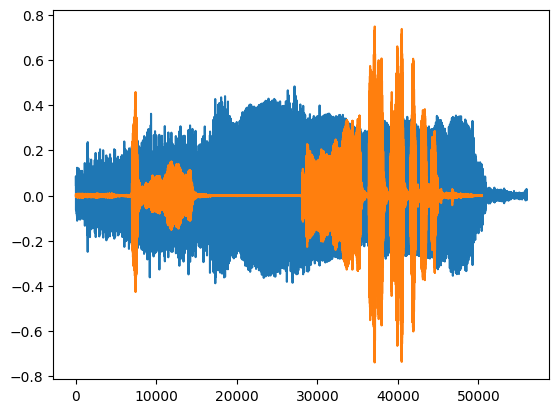

In [ ]:
wave = load_wav_16k_mono(Capuchin_file)
nwave = load_wav_16k_mono(Not_Capuchin_file)

plt.plot(wave)
plt.plot(nwave)
plt.show()

# Create Dataset

In [ ]:
POS = os.path.join("/","root",".cache","kagglehub","datasets","kenjee","z-by-hp-unlocked-challenge-3-signal-processing","versions","1","Parsed_Capuchinbird_Clips")
NEG = os.path.join("/","root",".cache","kagglehub","datasets","kenjee","z-by-hp-unlocked-challenge-3-signal-processing","versions","1","Parsed_Not_Capuchinbird_Clips")

In [ ]:
pos = glob.glob(POS+"/*.wav")
neg = glob.glob(NEG+"/*.wav")

In [ ]:
pos_labels = [1]*len(pos)
neg_labels = [0]*len(neg)

In [ ]:
files = pos + neg
labels = pos_labels + neg_labels

# Avg Length of Bird Call

In [ ]:
length=[]
for file in pos:
  wave = load_wav_16k_mono(file)
  length.append(len(wave))

In [ ]:
np.mean(length)/16000

np.float64(3.384792914746544)

In [ ]:
np.min(length)/16000

np.float64(2.0)

In [ ]:
np.max(length)/16000

np.float64(5.0)

# Spectrogram

In [ ]:
def preprocess(file_path,label):
  wav = load_wav_16k_mono(file_path)
  wav = wav[:48000]
  wav = torch.nn.functional.pad(wav,(0,48000-wav.shape[0]))
  spectrogram = torchaudio.transforms.Spectrogram(n_fft = 320, hop_length = 32)(wav)
  spectrogram = spectrogram.unsqueeze(0)
  return spectrogram, label

# Test Spectrogram

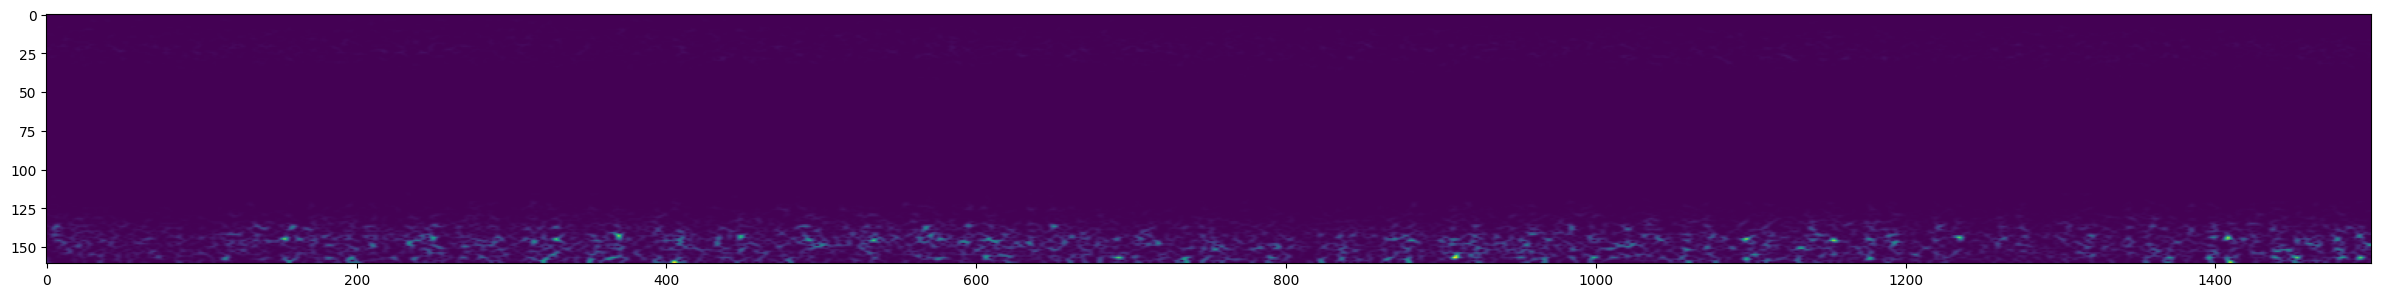

In [ ]:
file_path = files[np.random.randint(0,810)]
spectrogram, label= preprocess(file_path,1)
plt.figure(figsize=(30,20))
plt.imshow(spectrogram.squeeze(0))
plt.show()

# Training and Testing Partition

In [ ]:
class AudioDataset(torch.utils.data.Dataset):
  def __init__(self,files,labels):
    self.files = files
    self.labels = labels

  def __len__(self):
    return len(self.files)

  def __getitem__(self,idx):
    filepath = self.files[idx]
    label = self.labels[idx]
    spectrogram, label= preprocess(filepath,label)
    return spectrogram,label

In [ ]:
dataset = AudioDataset(files,labels)

In [ ]:
Train_set, test_set = torch.utils.data.random_split(dataset,[0.7,0.3])

In [ ]:
Train = torch.utils.data.DataLoader(Train_set, batch_size = 16,
                            shuffle = True,
                            num_workers=2,
                            prefetch_factor=4)
Test = torch.utils.data.DataLoader(test_set, batch_size = 16,
                            shuffle = False,
                            num_workers=2,
                            prefetch_factor=4)

In [ ]:
sample, label = next(iter(Train))
label

tensor([1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1])

# Deep Learning Model

In [ ]:
class CNN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = torch.nn.Conv2d(1,16,3)
    self.relu = torch.nn.ReLU()
    self.pool = torch.nn.MaxPool2d(2,2)
    self.conv2 = torch.nn.Conv2d(16,16,3)
    self.flat = torch.nn.Flatten()
    self.fc1 = torch.nn.Linear(373*38*16,128)
    self.sigm = torch.nn.Sigmoid()
    self.fc2 = torch.nn.Linear(128,1)
  def forward(self,x):
    x = self.pool(self.relu(self.conv1(x)))
    x = self.pool(self.relu(self.conv2(x)))
    x = self.flat(x)
    x = self.relu(self.fc1(x))
    x = self.sigm(self.fc2(x))
    return x


In [ ]:
torch.manual_seed(41)
cnn = CNN()
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.0001)

In [ ]:
cnn

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=226784, out_features=128, bias=True)
  (sigm): Sigmoid()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

# Training

In [ ]:
train_losses=[]
test_losses=[]
train_correct=[]
test_correct=[]
for epoch in range(4):
  trn_corr=0
  tst_corr=0

  for i, (trn_spec,trn_label) in enumerate(Train):
    i+=1
    train_prediction = cnn(trn_spec)
    loss = criterion(train_prediction , trn_label.float().unsqueeze(1))
    predicted=(torch.sigmoid(train_prediction)>0.5).float()
    batch_corr = (predicted == trn_label.float().unsqueeze(1)).sum()
    trn_corr += batch_corr
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"\rEpoch : {epoch} Batch : {i} Loss: {loss.item()}")
  train_losses.append(loss)
  train_correct.append(trn_corr/len(Train))
  with torch.no_grad():
    for i, (tst_spec,tst_label) in enumerate(Test):
      i+=1
      test_prediction = cnn(tst_spec)
      predicted=(torch.sigmoid(test_prediction)>0.5).float()
      batch_corr = (predicted == tst_label.float().unsqueeze(1)).sum()
      tst_corr += batch_corr
      loss = criterion(test_prediction , tst_label.float().unsqueeze(1))
    test_losses.append(loss)
    test_correct.append(tst_corr/len(Test))

Epoch : 0 Batch : 1 Loss: 0.807162344455719
Epoch : 0 Batch : 2 Loss: 6.300724506378174
Epoch : 0 Batch : 3 Loss: 0.43809792399406433
Epoch : 0 Batch : 4 Loss: 0.5211994647979736
Epoch : 0 Batch : 5 Loss: 9.445497512817383
Epoch : 0 Batch : 6 Loss: 6.9421610832214355
Epoch : 0 Batch : 7 Loss: 6.352092742919922
Epoch : 0 Batch : 8 Loss: 19.052820205688477
Epoch : 0 Batch : 9 Loss: 0.07518143951892853
Epoch : 0 Batch : 10 Loss: 19.64714241027832
Epoch : 0 Batch : 11 Loss: 0.311420738697052
Epoch : 0 Batch : 12 Loss: 0.32390251755714417
Epoch : 0 Batch : 13 Loss: 0.19178810715675354
Epoch : 0 Batch : 14 Loss: 0.4892031252384186
Epoch : 0 Batch : 15 Loss: 0.23342137038707733
Epoch : 0 Batch : 16 Loss: 0.028449954465031624
Epoch : 0 Batch : 17 Loss: 13.287924766540527
Epoch : 0 Batch : 18 Loss: 0.16347795724868774
Epoch : 0 Batch : 19 Loss: 0.17832259833812714
Epoch : 0 Batch : 20 Loss: 6.271332263946533
Epoch : 0 Batch : 21 Loss: 0.07822722941637039
Epoch : 0 Batch : 22 Loss: 0.41023480892

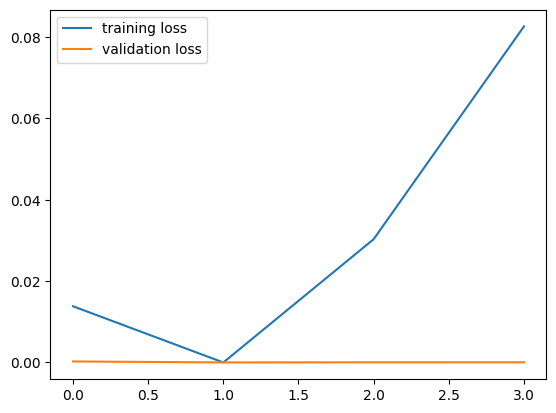

In [ ]:
train_losses = [tl.item() for tl in train_losses]
plt.plot(train_losses, label="training loss")
plt.plot(test_losses, label="validation loss")
plt.legend()

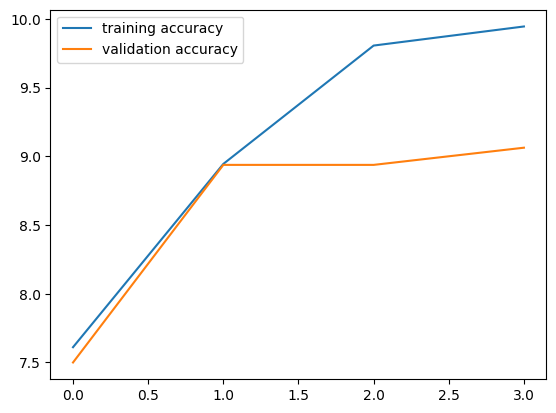

In [ ]:
train_correct = [tc.item() for tc in train_correct]
plt.plot(train_correct, label="training accuracy")
plt.plot(test_correct, label="validation accuracy")
plt.legend()

# Testing 1 batch

In [ ]:
x_test, y_test = next(iter(Test))
yhat = cnn(x_test)

In [ ]:
yhat = [1 if prediction > 0.5 else 0 for prediction in yhat]
print(sum(yhat))
print(sum(y_test))

3
tensor(5)
